# XGBoost — Base 2

Este notebook executa o modelo de especialização XGBoost com validação temporal. Ele é autocontido e usa os caminhos canônicos `data/base_02/` e `notebooks/` da estrutura atual do projeto. A análise conceitual e comparativa das cinco bases está em `docs/modelo_xgboost.md`.

## Protocolo

- Mesmas features, origem, horizonte e corte de teste do Random Forest desta base.
- Alvo de um passo e persistência como referência.
- Busca aleatória em duas etapas: 120 configurações amplas e 30 refinadas.
- Três dobras expansivas com purga de alvos que alcançam a validação.
- Parâmetros congelados antes do teste final.
- Walk-forward expansivo, com somente alvos disponíveis em cada reajuste.
- Gain e Permutation Importance, resíduos, ACF e Ljung–Box.

Por padrão são avaliadas as 150 configurações. Para uma verificação rápida, defina a variável de ambiente `XGBOOST_SMOKE_TEST=1` antes de executar o notebook.


In [1]:
import hashlib
import itertools
import json
import math
import os
import platform
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import xgboost
from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from xgboost import XGBRegressor


def encontrar_raiz():
    atual = Path.cwd().resolve()
    for raiz in (atual, *atual.parents):
        if (raiz / "pyproject.toml").is_file() and (raiz / "data").is_dir():
            return raiz
    raise FileNotFoundError("Raiz do projeto não encontrada; execute dentro do repositório.")


ROOT = encontrar_raiz()
SMOKE_TEST = os.getenv("XGBOOST_SMOKE_TEST", "0") == "1"
RUN_LABEL = "smoke" if SMOKE_TEST else "full"
N_ITER_AMPLA = 2 if SMOKE_TEST else 120
N_ITER_REFINADA = 1 if SMOKE_TEST else 30
N_SPLITS = 3
PERMUTATION_REPEATS = 1 if SMOKE_TEST else 3
PERMUTATION_MAX_ROWS = 200 if SMOKE_TEST else 500
XGBOOST_DEVICE = os.getenv("XGBOOST_DEVICE", "cpu")
TEMP_ROOT = Path(tempfile.gettempdir()) / "trabalho_daniel_xgboost"
SUMMARY_DIR = TEMP_ROOT / "summary"
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)
print("Raiz:", ROOT)
print("Modo:", "TESTE REDUZIDO" if SMOKE_TEST else "BUSCA COMPLETA (150 candidatos)")
print("XGBoost:", xgboost.__version__, "| dispositivo:", XGBOOST_DEVICE)


Raiz: C:\Users\giovannetorquato-ieg\OneDrive - Instituto J&F\Germinare\Terceiro Ano\Séries Temporais\Praticas\Trabalho XGBoost\TrabalhoDanielModelos
Modo: BUSCA COMPLETA (150 candidatos)
XGBoost: 3.4.1 | dispositivo: cpu


In [2]:
BASE_NUMBER=2; BASE_NAME="Tráfego horário"; DATA_PATH=ROOT/"data/base_02/prepared.csv"
TIME_COL="date_time"; TARGET_COL="traffic_volume"; EXTERNAL_COLS=["is_holiday","temp","rain_1h","snow_1h","clouds_all"]
EXPECTED_STEP=pd.Timedelta("1h"); FREQUENCY="h"; TRAIN_RATIO=.8; LAGS=[1,2,3,24,48,168]; WINDOWS=[24,168]
AVAILABILITY={c:("na_origem",0) for c in EXTERNAL_COLS}; AVAILABILITY["is_holiday"]=("conhecido_antecipadamente",0)
TUNING_MAX_ROWS=None; EXPECTED_FEATURE_COUNT=22; RANDOM_STATE=42; LJUNG_LAGS=[1,24,48,168]; np.random.seed(RANDOM_STATE)


## Funcionamento e intuição

O XGBoost constrói árvores de decisão sequencialmente. Cada nova árvore aproxima o gradiente do erro deixado pelo conjunto anterior; a previsão final é a soma das contribuições das árvores. A regularização da complexidade das árvores, a contração por `learning_rate` e a amostragem de linhas e colunas reduzem sobreajuste.

O método não exige normalização das variáveis nem linearidade, mas pressupõe que o padrão aprendido do passado seja útil no futuro. Em séries temporais isso exige transformar a sequência em uma tabela causal: lags, janelas e estados externos precisam conter apenas informação disponível na origem da previsão.

### Hiperparâmetros principais

- `n_estimators`: quantidade de árvores; mais árvores elevam capacidade e custo.
- `learning_rate`: contribuição de cada árvore; valores menores normalmente exigem mais árvores.
- `max_depth` e `min_child_weight`: controlam complexidade e especialização das folhas.
- `subsample` e `colsample_bytree`: amostram linhas e features, adicionando regularização.
- `reg_alpha` e `reg_lambda`: penalizações L1 e L2.

A otimização abaixo usa apenas o treino. Gain mede a redução de perda atribuída às divisões de cada feature. Permutation Importance mede quanto o MAE piora ao embaralhar a feature em blocos fora da amostra. Nenhuma delas prova causalidade; features correlacionadas podem dividir ou deslocar importância.


In [3]:
GRADE_XGBOOST = {
    "n_estimators": (100, 200, 400, 800),
    "learning_rate": (0.02, 0.05, 0.10),
    "max_depth": (2, 3, 5, 7),
    "min_child_weight": (1, 5, 10),
    "subsample": (0.7, 0.9, 1.0),
    "colsample_bytree": (0.6, 0.8, 1.0),
    "reg_alpha": (0.0, 0.1),
    "reg_lambda": (1.0, 5.0),
}


def json_default(value):
    if isinstance(value, np.integer): return int(value)
    if isinstance(value, np.floating): return float(value)
    if isinstance(value, np.bool_): return bool(value)
    if isinstance(value, (pd.Timestamp, Path)): return str(value)
    raise TypeError(f"Tipo não serializável: {type(value)}")


def purged_time_series_splits(origin_time, target_time, n_splits=3):
    origens = pd.Series(pd.to_datetime(origin_time, errors="raise")).reset_index(drop=True)
    alvos = pd.Series(pd.to_datetime(target_time, errors="raise")).reset_index(drop=True)
    if len(origens) != len(alvos) or len(origens) < n_splits + 1:
        raise ValueError("Amostras insuficientes ou vetores temporais incompatíveis.")
    if origens.isna().any() or alvos.isna().any() or not origens.is_monotonic_increasing:
        raise ValueError("Datas inválidas ou fora de ordem.")
    if not alvos.gt(origens).all():
        raise ValueError("Cada alvo deve ser posterior à origem.")
    tamanho = len(origens) // (n_splits + 1)
    splits = []
    for dobra in range(n_splits):
        inicio = len(origens) - (n_splits - dobra) * tamanho
        fim = len(origens) if dobra == n_splits - 1 else inicio + tamanho
        validacao = np.arange(inicio, fim, dtype=int)
        ajuste = np.flatnonzero((np.arange(len(origens)) < inicio) & (alvos <= origens.iloc[inicio]))
        if not len(ajuste) or not len(validacao):
            raise ValueError("A purga produziu uma dobra vazia.")
        assert alvos.iloc[ajuste].max() <= origens.iloc[validacao].min()
        splits.append((ajuste, validacao))
    return splits


def chronological_train_test(quadro, train_ratio, origin_col, target_time_col):
    corte = int(len(quadro) * train_ratio)
    if corte <= 0 or corte >= len(quadro):
        raise ValueError("Corte temporal produz treino ou teste vazio.")
    inicio_teste = quadro.iloc[corte][origin_col]
    treino = quadro.iloc[:corte]
    treino = treino.loc[treino[target_time_col] <= inicio_teste].reset_index(drop=True)
    teste = quadro.iloc[corte:].reset_index(drop=True)
    if treino.empty or teste.empty:
        raise ValueError("Purga na fronteira produziu conjunto vazio.")
    assert treino[target_time_col].max() <= teste[origin_col].min()
    return treino, teste


def sample_grid(grade, n_iter, random_state):
    nomes = list(grade)
    combinacoes = [dict(zip(nomes, valores)) for valores in itertools.product(*(grade[n] for n in nomes))]
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(combinacoes), size=min(n_iter, len(combinacoes)), replace=False)
    return [combinacoes[int(i)] for i in indices]


def refined_grid(best):
    def ints(key, offsets, minimum=1):
        return tuple(sorted({max(minimum, int(best[key]) + d) for d in offsets}))
    def bounded(key, factors, minimum, maximum):
        return tuple(sorted({round(min(maximum, max(minimum, float(best[key]) * f)), 4) for f in factors}))
    return {
        "n_estimators": ints("n_estimators", (-100, -50, 0, 50, 100), 50),
        "learning_rate": bounded("learning_rate", (.5, .75, 1, 1.25, 1.5), .005, .3),
        "max_depth": ints("max_depth", (-2, -1, 0, 1, 2)),
        "min_child_weight": ints("min_child_weight", (-2, -1, 0, 1, 2)),
        "subsample": bounded("subsample", (.85, 1, 1.15), .5, 1),
        "colsample_bytree": bounded("colsample_bytree", (.85, 1, 1.15), .5, 1),
        "reg_alpha": tuple(sorted({0., round(float(best["reg_alpha"]) / 2, 4), float(best["reg_alpha"]), round(float(best["reg_alpha"]) * 2 + .05, 4)})),
        "reg_lambda": bounded("reg_lambda", (.5, .75, 1, 1.5, 2), .1, 20),
    }


def typed_params(params):
    saida = dict(params)
    for key in ("n_estimators", "max_depth", "min_child_weight"):
        saida[key] = int(saida[key])
    for key in ("learning_rate", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda"):
        saida[key] = float(saida[key])
    return saida


def estimator_factory(params):
    kwargs = {
        **typed_params(params), "objective": "reg:squarederror", "random_state": RANDOM_STATE,
        "n_jobs": -1, "tree_method": "hist", "verbosity": 0,
    }
    if XGBOOST_DEVICE != "cpu":
        kwargs["device"] = XGBOOST_DEVICE
    return XGBRegressor(**kwargs)


def candidate_key(stage, params):
    payload = {"signature": RUN_SIGNATURE, "stage": stage, "params": typed_params(params)}
    return json.dumps(payload, sort_keys=True, ensure_ascii=False)


def temporal_search(quadro, grade, n_iter, stage, random_state):
    candidates = sample_grid(grade, n_iter, random_state)
    checkpoint = CHECKPOINT_DIR / f"search_{stage}.jsonl"
    registros = {}
    if checkpoint.exists():
        for line in checkpoint.read_text(encoding="utf-8").splitlines():
            try:
                row = json.loads(line)
                registros[row["candidate_key"]] = row
            except (json.JSONDecodeError, KeyError):
                continue
    splits = purged_time_series_splits(tuning_df[ORIGIN_COL], tuning_df[TARGET_TIME_COL], N_SPLITS)
    start_all = time.perf_counter()
    for candidate_id, params in enumerate(candidates, 1):
        key = candidate_key(stage, params)
        if key in registros:
            continue
        started = time.perf_counter()
        try:
            fold_mae = []
            for fit_idx, validation_idx in splits:
                model = estimator_factory(params)
                model.fit(quadro.iloc[fit_idx][FEATURES], quadro.iloc[fit_idx][MODEL_TARGET])
                pred = model.predict(quadro.iloc[validation_idx][FEATURES])
                fold_mae.append(mean_absolute_error(quadro.iloc[validation_idx][MODEL_TARGET], pred))
            row = {
                "candidate_key": key, "candidate_id": candidate_id, "stage": stage, "status": "ok",
                **typed_params(params), "mean_validation_mae": float(np.mean(fold_mae)),
                "std_validation_mae": float(np.std(fold_mae, ddof=1)),
                "fit_seconds": time.perf_counter() - started, "error": "",
            }
        except Exception as exc:
            row = {
                "candidate_key": key, "candidate_id": candidate_id, "stage": stage, "status": "erro",
                **typed_params(params), "mean_validation_mae": None, "std_validation_mae": None,
                "fit_seconds": time.perf_counter() - started, "error": str(exc),
            }
        with checkpoint.open("a", encoding="utf-8") as stream:
            stream.write(json.dumps(row, ensure_ascii=False, default=json_default) + "\n")
        registros[key] = row
        print(f"[{stage} {candidate_id:>3}/{len(candidates)}] status={row['status']} MAE={row['mean_validation_mae']} tempo={row['fit_seconds']:.2f}s")
    current_keys = {candidate_key(stage, p) for p in candidates}
    frame = pd.DataFrame([registros[k] for k in current_keys if k in registros])
    valid = frame.loc[frame.status.eq("ok")].sort_values(["mean_validation_mae", "std_validation_mae", "candidate_id"]).reset_index(drop=True)
    if valid.empty:
        raise RuntimeError(f"Nenhum candidato válido na etapa {stage}.")
    names = list(grade)
    best = typed_params({name: valid.iloc[0][name] for name in names})
    print(f"Etapa {stage}: {len(frame)} candidatos; tempo desta chamada={time.perf_counter()-start_all:.2f}s")
    return best, frame.sort_values(["status", "mean_validation_mae"], ascending=[False, True]).reset_index(drop=True)


def walk_forward(treino, teste, params, refit_every):
    predictions, fits, importance = [], [], []
    for block_start in range(0, len(teste), refit_every):
        block_end = min(block_start + refit_every, len(teste))
        block = teste.iloc[block_start:block_end]
        refit_origin = block.iloc[0][ORIGIN_COL]
        history = pd.concat([treino, teste.loc[teste[TARGET_TIME_COL] <= refit_origin]], ignore_index=True)
        cutoff = history[TARGET_TIME_COL].max()
        assert cutoff <= refit_origin
        model = estimator_factory(params)
        started = time.perf_counter()
        model.fit(history[FEATURES], history[MODEL_TARGET])
        fit_seconds = time.perf_counter() - started
        values = np.asarray(model.predict(block[FEATURES]), dtype=float)
        if not np.isfinite(values).all():
            raise ValueError("Previsões não finitas.")
        for (_, row), value in zip(block.iterrows(), values):
            predictions.append({
                ORIGIN_COL: row[ORIGIN_COL], TARGET_TIME_COL: row[TARGET_TIME_COL],
                "y_true": row[MODEL_TARGET], "y_pred": float(value),
                "model_refit_origin": refit_origin, "training_target_cutoff": cutoff,
            })
        fits.append({
            "model_refit_origin": refit_origin, "training_target_cutoff": cutoff,
            "training_rows": len(history), "block_start": block_start,
            "block_end_exclusive": block_end, "fit_seconds": fit_seconds,
        })
        perm_block = block if len(block) <= PERMUTATION_MAX_ROWS else block.sample(PERMUTATION_MAX_ROWS, random_state=RANDOM_STATE)
        perm = permutation_importance(
            model, perm_block[FEATURES], perm_block[MODEL_TARGET], scoring="neg_mean_absolute_error",
            n_repeats=PERMUTATION_REPEATS, random_state=RANDOM_STATE, n_jobs=1,
        )
        gain = model.feature_importances_
        for pos, feature in enumerate(FEATURES):
            importance.append({
                "model_refit_origin": refit_origin, "feature": feature, "gain": float(gain[pos]),
                "permutation_mean": float(perm.importances_mean[pos]),
                "permutation_std": float(perm.importances_std[pos]),
            })
    return pd.DataFrame(predictions), pd.DataFrame(fits), pd.DataFrame(importance)


def level_metrics(real, predicted, level_t):
    real, predicted, level_t = map(lambda x: np.asarray(x, dtype=float), (real, predicted, level_t))
    return {
        "observacoes": len(real), "MAE": mean_absolute_error(real, predicted),
        "RMSE": mean_squared_error(real, predicted) ** .5,
        "MedAE": median_absolute_error(real, predicted), "R2": r2_score(real, predicted),
        "vies_medio": float(np.mean(real - predicted)),
        "acuracia_direcional": float(np.mean(np.sign(real-level_t) == np.sign(predicted-level_t))),
    }


def return_metrics(real_return, pred_return, price_t, real_price):
    real_return, pred_return, price_t, real_price = map(lambda x: np.asarray(x, dtype=float), (real_return, pred_return, price_t, real_price))
    pred_price = price_t * np.exp(pred_return)
    return {
        "observacoes": len(real_return), "MAE_retorno": mean_absolute_error(real_return, pred_return),
        "RMSE_retorno": mean_squared_error(real_return, pred_return) ** .5,
        "MedAE_retorno": median_absolute_error(real_return, pred_return),
        "R2_retorno": r2_score(real_return, pred_return),
        "vies_retorno": float(np.mean(real_return-pred_return)),
        "acuracia_direcional": float(np.mean(np.sign(real_return) == np.sign(pred_return))),
        "MAE_preco": mean_absolute_error(real_price, pred_price),
    }


In [4]:
def build_one_step_frame(dados):
    required = {TIME_COL, TARGET_COL, *EXTERNAL_COLS}
    missing = sorted(required.difference(dados.columns))
    if missing: raise KeyError(f"Colunas ausentes: {missing}")
    data = dados.copy()
    data[TIME_COL] = pd.to_datetime(data[TIME_COL], errors="raise")
    if data[TIME_COL].isna().any() or data[TIME_COL].duplicated().any() or not data[TIME_COL].is_monotonic_increasing:
        raise ValueError("Grade temporal inválida.")
    if not data[TIME_COL].diff().dropna().eq(EXPECTED_STEP).all():
        raise ValueError("A grade temporal precisa ser regular.")
    out = pd.DataFrame(index=data.index)
    out["origin_time"] = data[TIME_COL]
    out["target_time"] = data[TIME_COL].shift(-1)
    out["level_t"] = data[TARGET_COL]
    out["y_true"] = data[TARGET_COL].shift(-1)
    out["target_delta"] = out.y_true - out.level_t
    features = ["level_t"]
    for col in EXTERNAL_COLS:
        availability, lag = AVAILABILITY.get(col, ("na_origem", 0))
        if availability == "conhecido_antecipadamente":
            name, out_value = f"{col}_alvo", data[col].shift(-1)
        else:
            name, out_value = (f"{col}_t" if lag == 0 else f"{col}_lag_{lag}"), data[col].shift(lag)
        out[name] = out_value
        features.append(name)
    for lag in LAGS:
        name = f"target_lag_{lag}"; out[name] = data[TARGET_COL].shift(lag); features.append(name)
    prior = data[TARGET_COL].shift(1)
    for window in WINDOWS:
        roll = prior.rolling(window, min_periods=window)
        mean_name, std_name = f"target_mean_{window}", f"target_std_{window}"
        out[mean_name], out[std_name] = roll.mean(), roll.std(ddof=0)
        features.extend([mean_name, std_name])
    target_date = out.target_time
    for label, value, period in (("hour", target_date.dt.hour, 24), ("dow", target_date.dt.dayofweek, 7), ("month", target_date.dt.month-1, 12)):
        angle = 2*np.pi*value/period
        sin_name, cos_name = f"target_{label}_sin", f"target_{label}_cos"
        out[sin_name], out[cos_name] = np.sin(angle), np.cos(angle)
        features.extend([sin_name, cos_name])
    one_step = out.target_time.sub(out.origin_time).eq(EXPECTED_STEP)
    out = out.loc[one_step].dropna(subset=["origin_time", "target_time", "y_true", "target_delta", *features]).reset_index(drop=True)
    return out, features


raw = pd.read_csv(DATA_PATH, low_memory=False)
raw[TIME_COL] = pd.to_datetime(raw[TIME_COL], errors="raise")
raw = raw.sort_values(TIME_COL, kind="stable").reset_index(drop=True)
if BASE_NUMBER == 2:
    raw["is_holiday"] = raw["holiday"].notna().astype(int)
model_df, FEATURES = build_one_step_frame(raw)
assert len(FEATURES) == EXPECTED_FEATURE_COUNT, (len(FEATURES), EXPECTED_FEATURE_COUNT)
ORIGIN_COL, TARGET_TIME_COL, MODEL_TARGET = "origin_time", "target_time", "target_delta"
train_df, test_df = chronological_train_test(model_df, TRAIN_RATIO, ORIGIN_COL, TARGET_TIME_COL)
tuning_df = train_df.tail(TUNING_MAX_ROWS).reset_index(drop=True) if TUNING_MAX_ROWS else train_df
assert model_df[ORIGIN_COL].is_monotonic_increasing
assert np.isfinite(model_df[FEATURES].to_numpy(dtype=float)).all()
DATA_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
RUN_SIGNATURE = hashlib.sha256(json.dumps({"sha": DATA_SHA256, "features": FEATURES, "train": len(train_df), "mode": RUN_LABEL}, sort_keys=True).encode()).hexdigest()
CHECKPOINT_DIR = TEMP_ROOT / f"grupo{BASE_NUMBER}" / RUN_LABEL / RUN_SIGNATURE[:12]
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({"recorte": ["treino", "tuning", "teste"], "linhas": [len(train_df), len(tuning_df), len(test_df)]}))
print("Features:", len(FEATURES), "| teste:", test_df[ORIGIN_COL].min(), "→", test_df[ORIGIN_COL].max())
print("Checkpoints:", CHECKPOINT_DIR)


,recorte,linhas
0,treino,13486
1,tuning,13486
2,teste,3372


Features: 22 | teste: 2018-04-15 01:00:00 → 2018-09-30 22:00:00
Checkpoints: C:\Users\GIOVAN~1\AppData\Local\Temp\trabalho_daniel_xgboost\grupo2\full\c02eed5fdcbb


## Otimização temporal

A busca ampla explora regiões distintas; a etapa refinada amostra uma vizinhança do melhor candidato amplo. O ranking usa somente MAE de validação nas três dobras purgadas.


In [5]:
best_broad, broad_results = temporal_search(tuning_df, GRADE_XGBOOST, N_ITER_AMPLA, "ampla", RANDOM_STATE)
best_refined, refined_results = temporal_search(tuning_df, refined_grid(best_broad), N_ITER_REFINADA, "refinada", RANDOM_STATE + 1)
search_results = pd.concat([broad_results, refined_results], ignore_index=True)
valid_results = search_results.loc[search_results.status.eq("ok")].sort_values(["mean_validation_mae", "std_validation_mae", "candidate_id"]).reset_index(drop=True)
param_names = list(GRADE_XGBOOST)
best_params = typed_params({name: valid_results.iloc[0][name] for name in param_names})
FROZEN_PARAMS = json.dumps(best_params, sort_keys=True, default=json_default)
assert len(search_results) == N_ITER_AMPLA + N_ITER_REFINADA
print("Configuração congelada antes do teste:", FROZEN_PARAMS)
display(valid_results.head(15))


[ampla   1/120] status=ok MAE=204.36753866122368 tempo=6.12s


[ampla   2/120] status=ok MAE=175.4516636617419 tempo=2.01s


[ampla   3/120] status=ok MAE=331.97016926964847 tempo=0.98s


[ampla   4/120] status=ok MAE=179.11295391542293 tempo=5.45s


[ampla   5/120] status=ok MAE=222.79359196565701 tempo=2.05s


...

[refinada  27/30] status=ok MAE=171.02632120935695 tempo=14.38s


[refinada  28/30] status=ok MAE=171.53685484610628 tempo=15.43s


[refinada  29/30] status=ok MAE=169.80508279126525 tempo=15.48s


[refinada  30/30] status=ok MAE=172.78165694492995 tempo=13.21s
Etapa refinada: 30 candidatos; tempo desta chamada=384.77s
Configuração congelada antes do teste: {"colsample_bytree": 0.92, "learning_rate": 0.01, "max_depth": 9, "min_child_weight": 12, "n_estimators": 900, "reg_alpha": 0.05, "reg_lambda": 5.0, "subsample": 0.765}


,candidate_key,candidate_id,stage,status,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,mean_validation_mae,std_validation_mae,fit_seconds,error
0,"{""params"": {""colsample_bytree"": 0.92, ""learnin...",3,refinada,ok,900,0.010,9,12,0.765,0.92,0.05,5.00,169.182719,22.066824,18.862233,
1,"{""params"": {""colsample_bytree"": 0.92, ""learnin...",29,refinada,ok,800,0.020,8,8,0.900,0.92,0.05,10.00,169.805083,21.954145,15.480158,
2,"{""params"": {""colsample_bytree"": 0.8, ""learning...",14,refinada,ok,850,0.010,9,12,0.900,0.80,0.00,5.00,170.315573,22.636341,17.723278,
3,"{""params"": {""colsample_bytree"": 0.8, ""learning...",18,refinada,ok,750,0.015,9,12,0.765,0.80,0.00,3.75,170.487228,23.136445,15.816139,
4,"{""params"": {""colsample_bytree"": 0.8, ""learning...",27,refinada,ok,800,0.015,8,8,0.765,0.80,0.05,5.00,171.026321,22.847898,14.381893,
5,"{""params"": {""colsample_bytree"": 0.92, ""learnin...",12,refinada,ok,700,0.025,8,9,1.000,0.92,0.05,10.00,171.376143,22.552595,12.834874,
6,"{""params"": {""colsample_bytree"": 0.8, ""learning...",4,refinada,ok,750,0.015,9,10,1.000,0.80,0.00,3.75,171.386835,22.092859,15.974414,
7,"{""params"": {""colsample_bytree"": 0.68, ""learnin...",17,refinada,ok,750,0.015,9,9,0.765,0.68,0.05,7.50,171.405387,22.090476,15.440891,
8,"{""params"": {""colsample_bytree"": 0.68, ""learnin...",28,refinada,ok,750,0.010,8,8,0.900,0.68,0.05,2.50,171.536855,20.656052,15.434168,
9,"{""params"": {""colsample_bytree"": 0.8, ""learning...",46,ampla,ok,800,0.020,7,10,0.900,0.80,0.00,5.00,171.546808,22.599714,13.370412,


## Teste final walk-forward

A configuração acima é congelada. Em cada reajuste, entram apenas observações cujo alvo já ocorreu antes da origem do bloco previsto.


In [6]:
REFIT_EVERY = 1
evaluation_start = time.perf_counter()
core_predictions, fit_log, importance_long = walk_forward(train_df, test_df, best_params, REFIT_EVERY)
evaluation_seconds = time.perf_counter() - evaluation_start
assert json.dumps(best_params, sort_keys=True, default=json_default) == FROZEN_PARAMS
assert len(core_predictions) == len(test_df)
assert core_predictions[ORIGIN_COL].reset_index(drop=True).equals(test_df[ORIGIN_COL].reset_index(drop=True))
assert (core_predictions.training_target_cutoff < core_predictions[ORIGIN_COL]).all()
predictions = test_df[[ORIGIN_COL, TARGET_TIME_COL, "level_t", "y_true", MODEL_TARGET]].copy()
predictions["y_pred_delta_xgb"] = core_predictions.y_pred.to_numpy()
predictions["y_pred_xgb"] = predictions.level_t + predictions.y_pred_delta_xgb
predictions["y_pred_persistencia"] = predictions.level_t
predictions["residuo_xgb"] = predictions.y_true - predictions.y_pred_xgb
predictions["model_refit_origin"] = core_predictions.model_refit_origin.to_numpy()
predictions["training_target_cutoff"] = core_predictions.training_target_cutoff.to_numpy()
assert np.isfinite(predictions[["y_pred_delta_xgb", "y_pred_xgb"]]).all().all()
metrics = pd.DataFrame([
    {"modelo": "XGBoost", **level_metrics(predictions.y_true, predictions.y_pred_xgb, predictions.level_t)},
    {"modelo": "Persistência", **level_metrics(predictions.y_true, predictions.y_pred_persistencia, predictions.level_t)},
])
baseline_mae = metrics.loc[metrics.modelo.eq("Persistência"), "MAE"].iloc[0]
metrics["skill_MAE_vs_persistencia"] = 1 - metrics.MAE / baseline_mae


,modelo,observacoes,MAE,RMSE,MedAE,R2,vies_medio,acuracia_direcional,skill_MAE_vs_persistencia
0,XGBoost,3372,129.873248,203.494108,87.677841,0.989258,0.200965,0.935943,0.777646
1,Persistência,3372,584.084223,812.152047,459.000000,0.828902,0.732503,0.000297,0.000000


,lag,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
0,1,55.219361,1.078016e-13,True
1,24,164.212411,7.248729e-23,True
2,48,199.884707,1.946646e-20,True
3,168,403.924538,1.809741e-21,True


,feature,gain_mean,gain_std,permutation_mean,permutation_std
0,target_lag_3,0.333879,0.004025,215.755392,22.833708
1,target_hour_cos,0.215369,0.006419,345.445798,12.486015
2,target_hour_sin,0.176792,0.003257,132.687212,13.637701
3,target_lag_1,0.100704,0.001452,106.238252,9.384686
4,level_t,0.044519,0.000468,309.389002,12.511322
5,target_dow_sin,0.034114,0.000618,36.270804,5.433616
6,target_lag_2,0.027414,0.001284,23.828088,3.958616
7,target_lag_48,0.010171,0.000488,11.739225,2.121479
8,target_dow_cos,0.007995,0.000251,1.903282,0.741016
9,target_lag_168,0.006757,0.000240,9.680671,2.631883


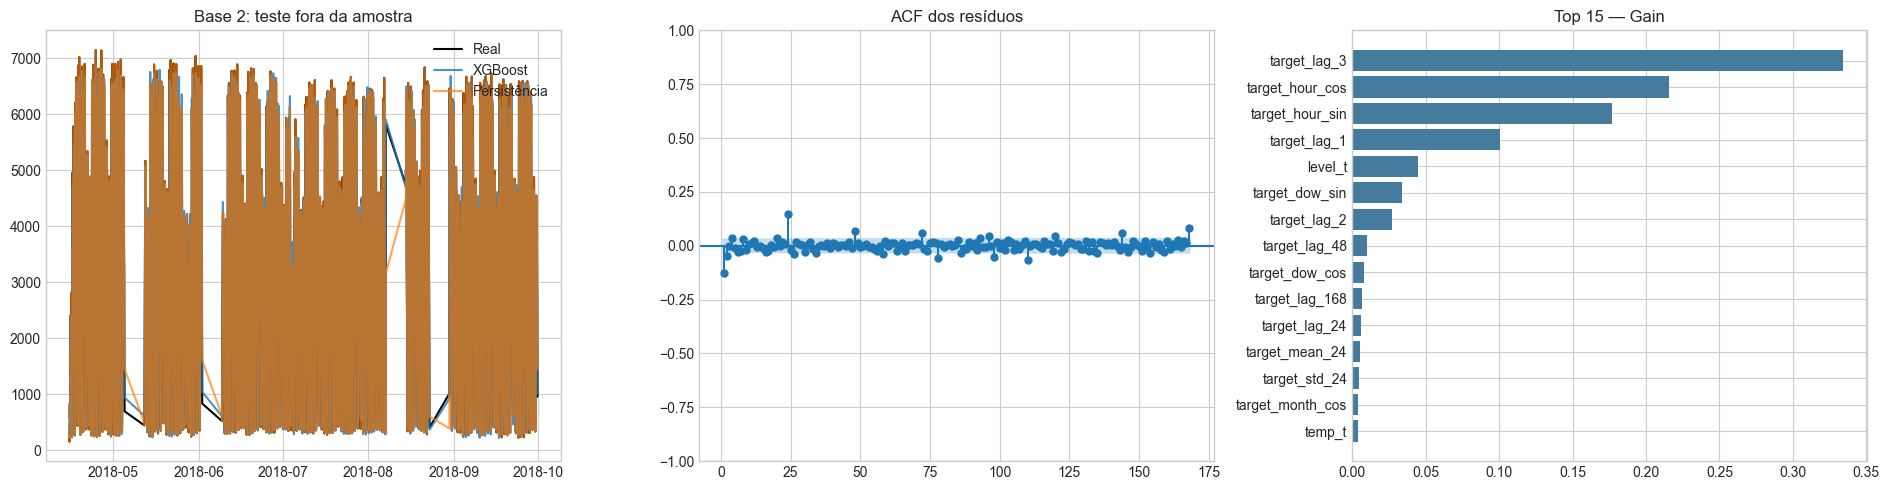

In [7]:
residual_col = "residual_return_xgb" if BASE_NUMBER == 5 else "residuo_xgb"
residuals = predictions[residual_col].dropna()
configured_lags = LJUNG_LAGS
usable_lags = [lag for lag in configured_lags if lag < len(residuals)]
ljung_box = acorr_ljungbox(residuals, lags=usable_lags, return_df=True).reset_index(names="lag")
ljung_box["rejeita_ruido_branco_5pct"] = ljung_box.lb_pvalue < .05
importance = importance_long.groupby("feature", as_index=False).agg(
    gain_mean=("gain", "mean"), gain_std=("gain", "std"),
    permutation_mean=("permutation_mean", "mean"), permutation_std=("permutation_mean", "std"),
).sort_values("gain_mean", ascending=False).reset_index(drop=True)

display(metrics)
display(ljung_box)
display(importance.head(20))
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
if BASE_NUMBER == 5:
    axes[0].plot(predictions.target_date, predictions.target_price_t_plus_1, label="Real", color="black")
    axes[0].plot(predictions.target_date, predictions.price_pred_xgb, label="XGBoost", alpha=.8)
    axes[0].plot(predictions.target_date, predictions.price_pred_persistencia, label="Persistência", alpha=.7)
else:
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_true, label="Real", color="black")
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_pred_xgb, label="XGBoost", alpha=.8)
    axes[0].plot(predictions[TARGET_TIME_COL], predictions.y_pred_persistencia, label="Persistência", alpha=.7)
axes[0].set_title(f"Base {BASE_NUMBER}: teste fora da amostra"); axes[0].legend()
plot_acf(residuals, lags=min(max(usable_lags), len(residuals)//2-1), zero=False, ax=axes[1], title="ACF dos resíduos")
top = importance.head(15).sort_values("gain_mean")
axes[2].barh(top.feature, top.gain_mean, color="#457b9d"); axes[2].set_title("Top 15 — Gain")
plt.tight_layout(); plt.show()


In [8]:
summary = {
    "base": BASE_NUMBER, "nome": BASE_NAME, "frequencia": FREQUENCY,
    "alvo": TARGET_COL, "observacoes_teste": len(test_df), "features": len(FEATURES),
    "mae_xgboost": float(metrics.loc[metrics.modelo.eq("XGBoost"), "MAE"].iloc[0]),
    "mae_persistencia": float(metrics.loc[metrics.modelo.eq("Persistência"), "MAE"].iloc[0]),
    "skill_vs_persistencia": float(metrics.loc[metrics.modelo.eq("XGBoost"), "skill_MAE_vs_persistencia"].iloc[0]),
    "best_params": best_params, "data_sha256": DATA_SHA256,
    "search_candidates": len(search_results), "refits": len(fit_log),
    "search_seconds_recorded": float(search_results.fit_seconds.sum()), "evaluation_seconds": evaluation_seconds,
}
(SUMMARY_DIR / f"base{BASE_NUMBER}.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=json_default), encoding="utf-8")
experiment_record = pd.DataFrame([{
    **summary, "features_list": json.dumps(FEATURES, ensure_ascii=False),
    "python": platform.python_version(), "pandas": pd.__version__, "numpy": np.__version__,
    "scikit_learn": sklearn.__version__, "statsmodels": statsmodels.__version__, "xgboost": xgboost.__version__,
    "checkpoint_dir": str(CHECKPOINT_DIR),
}])
display(experiment_record.T)
display(fit_log)


,0
base,2
nome,Tráfego horário
frequencia,h
alvo,traffic_volume
observacoes_teste,3372
features,22
mae_xgboost,129.873248
mae_persistencia,584.084223
skill_vs_persistencia,0.777646
best_params,"{'n_estimators': 900, 'learning_rate': 0.01, '..."


,model_refit_origin,training_target_cutoff,training_rows,block_start,block_end_exclusive,fit_seconds
0,2018-04-15 01:00:00,2018-04-15 00:00:00,13486,0,422,8.011986
1,2018-05-02 15:00:00,2018-05-02 14:00:00,13907,422,844,8.256968
2,2018-05-27 07:00:00,2018-05-27 06:00:00,14329,844,1266,8.162954
3,2018-06-20 23:00:00,2018-06-20 22:00:00,14751,1266,1688,8.556382
4,2018-07-08 13:00:00,2018-07-08 12:00:00,15173,1688,2110,8.579417
5,2018-07-26 03:00:00,2018-07-26 02:00:00,15595,2110,2532,9.198360
6,2018-08-19 21:00:00,2018-08-19 20:00:00,16017,2532,2954,8.345622
7,2018-09-13 13:00:00,2018-09-13 12:00:00,16439,2954,3372,8.607373


## Interpretação, limitações e pontos de atenção

O desempenho deve ser interpretado contra a persistência e dentro da escala desta base. Um ganho pequeno ou negativo indica que as relações não lineares aprendidas não compensaram a força do último valor observado. Diferenças entre bases podem vir da frequência, quantidade de treino, força de autocorrelação, ruído, mudanças de regime e qualidade ou disponibilidade das covariáveis externas.

O XGBoost não modela tempo automaticamente: toda estrutura temporal vem das features. Gain e Permutation Importance são descritivas, não causais. Na Base 5, as duas taxas externas permanecem provisórias e exigem homologação de fonte, unidade e disponibilidade. Horizonte, origens e teste continuam espelhados do RF até homologação definitiva do protocolo comum.

Os checkpoints e resumos usados na execução ficam no diretório temporário mostrado pelo notebook; nenhum artefato em `results/` é criado.
